In [1]:
#### ----------------------------------------------------------------------------------------------------------------------------------------------------------
#### author: Ranjan Barman, date: Jul 23, 2025 (Modified for POST_NAT_BRCA)
#### External prediction using trained models based on HoverNet Predicted Immune-Only NPIFs (All tiles)
#### ---------------------------------------------------------------------------------------------------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, roc_auc_score, roc_curve, auc

# Set working directory
_wpath_ = "/data/Lab_ruppin/Ranjan/HnE/"
os.chdir(_wpath_)
print(f"Working directory = {_wpath_}\n")



Working directory = /data/Lab_ruppin/Ranjan/HnE/



In [2]:
# Dataset
dataset_name = "POST_NAT_BRCA"

# File paths (Top 25% immune-only NPIFs with subtype info)
external_file = f"{dataset_name}/outputs/HoverNet/Subtypes/HoverNet_ImmuneOnly_NPIFs_All_Tiles_POST_NAT_BRCA_Mapped_BRCA_Status.csv"
out_path = f"{dataset_name}/outputs/HoverNet/Subtypes/POST_NAT_BRCA_Predictions/HoverNet_ImmuneOnly_All_NPIFs_All_Tiles_Binary_Subtypes/"

# Path to saved TCGA-trained models
model_path = "TCGA_BRCA_FFPE/outputs/HoverNet/Subtypes/Prediction_results_HoverNet_ImmuneOnly_All_HoverNet_NPIFs_All_Tiles_Binary_Subtypes/saved_models/"
os.makedirs(out_path, exist_ok=True)

# Subtype definitions
subtype_names_3 = ['HER2_Positive', 'HR_Positive', 'TNBC_3']
subtype_names_4 = ['HR+', 'TNBC_4', 'TPBC', 'HER2+']
all_subtypes = subtype_names_3 + subtype_names_4

# Load POST_NAT_BRCA immune-only NPIFs + subtype labels
df_external = pd.read_csv(external_file)
df_external.columns = df_external.columns.str.strip()

# Filter to keep only samples with valid binary status
df_external = df_external[df_external[['HER2_Status', 'PR_Status', 'ER_Status']].isin(["Positive", "Negative"]).all(axis=1)].copy()

df_external



,Patient_ID,HER2_Status,ER_Status,PR_Status,Clinical_subtype,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
0,P1,Negative,Positive,Positive,HR+,5.680922,3.263634,2.376652,9.342079,0.640795,0.801047,2.126056,0.684666,0.426367,1.806510,0.149244,0.068583
1,P10,Negative,Positive,Positive,HR+,5.893770,3.336161,2.400254,9.515610,0.649265,0.796498,2.447113,0.770223,0.467471,2.039873,0.148196,0.069349
2,P11,Negative,Negative,Negative,TNBC,6.778583,3.510195,2.609509,10.148907,0.624076,0.809013,2.461946,0.732774,0.449556,1.909252,0.148355,0.060563
3,P12,Negative,Negative,Negative,TNBC,6.801173,3.607990,2.545226,10.230945,0.660885,0.795050,2.755116,0.844042,0.481877,2.142935,0.151199,0.068087
4,P13,Negative,Negative,Negative,TNBC,7.986337,3.784082,2.778534,10.954229,0.639125,0.791578,4.145479,0.974017,0.721297,2.785051,0.147258,0.066604
5,P14,Negative,Positive,Positive,HR+,6.239375,3.445621,2.460010,9.813096,0.656056,0.794231,2.423127,0.760337,0.462933,1.992362,0.146668,0.067512
6,P15,Negative,Positive,Positive,HR+,6.457001,3.526905,2.477085,9.992821,0.668401,0.790029,2.681561,0.822846,0.497472,2.167903,0.145152,0.069314
7,P16,Negative,Positive,Positive,HR+,5.781735,3.307597,2.381659,9.423323,0.644420,0.800622,2.275362,0.762955,0.429203,1.954134,0.152395,0.069323
8,P17,Negative,Positive,Positive,HR+,5.928892,3.356636,2.404426,9.565747,0.651870,0.793482,2.375010,0.756895,0.471440,1.998427,0.149832,0.070749
9,P18,Negative,Negative,Negative,TNBC,5.518564,3.246748,2.324519,9.239448,0.651114,0.797479,2.017974,0.706341,0.405652,1.825018,0.150332,0.071618


In [3]:
# Define subtype truth labels
def define_true_subtypes(df):
    HER2 = df['HER2_Status'] == 'Positive'
    ER = df['ER_Status'] == 'Positive'
    PR = df['PR_Status'] == 'Positive'

    df['HER2_Positive'] = HER2.astype(int)
    df['HR_Positive'] = ((ER | PR) & ~HER2).astype(int)
    df['TNBC_3'] = (~HER2 & ~ER & ~PR).astype(int)

    df['HR+'] = (ER & ~HER2).astype(int)
    df['TNBC_4'] = (~ER & ~HER2).astype(int)
    df['TPBC'] = (ER & HER2).astype(int)
    df['HER2+'] = (~ER & HER2).astype(int)
    return df

df_external = define_true_subtypes(df_external)

# Define feature columns
columns_to_exclude = ['sample_id', 'Patient_ID', 'HER2_Status', 'PR_Status', 'ER_Status', 'Clinical_subtype'] + all_subtypes
feature_columns = [col for col in df_external.columns if col not in columns_to_exclude]
X_external = df_external[feature_columns].copy()

X_external


,Mean Area,Mean Major Axis,Mean Minor Axis,Mean Perimeter,Mean Eccentricity,Mean Circularity,Std Area,Std Major Axis,Std Minor Axis,Std Perimeter,Std Eccentricity,Std Circularity
0,5.680922,3.263634,2.376652,9.342079,0.640795,0.801047,2.126056,0.684666,0.426367,1.806510,0.149244,0.068583
1,5.893770,3.336161,2.400254,9.515610,0.649265,0.796498,2.447113,0.770223,0.467471,2.039873,0.148196,0.069349
2,6.778583,3.510195,2.609509,10.148907,0.624076,0.809013,2.461946,0.732774,0.449556,1.909252,0.148355,0.060563
3,6.801173,3.607990,2.545226,10.230945,0.660885,0.795050,2.755116,0.844042,0.481877,2.142935,0.151199,0.068087
4,7.986337,3.784082,2.778534,10.954229,0.639125,0.791578,4.145479,0.974017,0.721297,2.785051,0.147258,0.066604
5,6.239375,3.445621,2.460010,9.813096,0.656056,0.794231,2.423127,0.760337,0.462933,1.992362,0.146668,0.067512
6,6.457001,3.526905,2.477085,9.992821,0.668401,0.790029,2.681561,0.822846,0.497472,2.167903,0.145152,0.069314
7,5.781735,3.307597,2.381659,9.423323,0.644420,0.800622,2.275362,0.762955,0.429203,1.954134,0.152395,0.069323
8,5.928892,3.356636,2.404426,9.565747,0.651870,0.793482,2.375010,0.756895,0.471440,1.998427,0.149832,0.070749
9,5.518564,3.246748,2.324519,9.239448,0.651114,0.797479,2.017974,0.706341,0.405652,1.825018,0.150332,0.071618


In [4]:
# Sample ID list
external_ids = df_external['Patient_ID'].reset_index(drop=True)

# Initialize dataframe to store predictions
external_predictions_df = pd.DataFrame({'Patient_ID': external_ids})
external_predictions_df.set_index('Patient_ID', inplace=True)

# Store true labels
for subtype in all_subtypes:
    external_predictions_df[f'true_label_{subtype}'] = df_external.set_index("Patient_ID")[subtype]

# Prediction function
def predict_external_subtype(subtype_name):
    print(f"\nPredicting subtype: {subtype_name}")
    model_files = sorted([f for f in os.listdir(model_path) if f.startswith(f"{subtype_name}_model_fold_")])
    if not model_files:
        print(f"No model found for {subtype_name}")
        return

    all_preds = []
    for fold_file in model_files:
        model = joblib.load(os.path.join(model_path, fold_file))
        scaler = model.named_steps['scaler']
        classifier = model.named_steps['classifier']

        trained_features = classifier.feature_names_in_ if hasattr(classifier, 'feature_names_in_') else feature_columns
        X_test = X_external[trained_features].copy()
        X_test_scaled = scaler.transform(X_test)

        y_pred = classifier.predict_proba(X_test_scaled)[:, 1]
        all_preds.append(y_pred)

    mean_preds = np.mean(np.column_stack(all_preds), axis=1)
    external_predictions_df[f'predicted_probability_{subtype_name}'] = mean_preds

# Run prediction for all subtypes
for subtype in all_subtypes:
    predict_external_subtype(subtype)

# Save prediction output
output_csv = os.path.join(out_path, "External_POST_NAT_BRCA_Predictions_All_HoverNet_NPIFs_All_Tiles_Immune_Only_Subtypes.csv")
external_predictions_df.to_csv(output_csv)
print(f"\n Predictions saved to: {output_csv}")



Predicting subtype: HER2_Positive

Predicting subtype: HR_Positive

Predicting subtype: TNBC_3

Predicting subtype: HR+

Predicting subtype: TNBC_4

Predicting subtype: TPBC

Predicting subtype: HER2+

 Predictions saved to: POST_NAT_BRCA/outputs/HoverNet/Subtypes/POST_NAT_BRCA_Predictions/HoverNet_ImmuneOnly_All_NPIFs_All_Tiles_Binary_Subtypes/External_POST_NAT_BRCA_Predictions_All_HoverNet_NPIFs_All_Tiles_Immune_Only_Subtypes.csv


In [5]:
external_predictions_df

,true_label_HER2_Positive,true_label_HR_Positive,true_label_TNBC_3,true_label_HR+,true_label_TNBC_4,true_label_TPBC,true_label_HER2+,predicted_probability_HER2_Positive,predicted_probability_HR_Positive,predicted_probability_TNBC_3,predicted_probability_HR+,predicted_probability_TNBC_4,predicted_probability_TPBC,predicted_probability_HER2+
Patient_ID,,,,,,,,,,,,,,
P1,0,1,0,1,0,0,0,0.331951,0.705460,0.294294,0.696385,0.323368,0.379401,0.420057
P10,0,1,0,1,0,0,0,0.315096,0.712023,0.250088,0.706235,0.278466,0.362523,0.384880
P11,0,0,1,0,1,0,0,0.257660,0.685988,0.349576,0.694860,0.403135,0.255473,0.340717
P12,0,0,1,0,1,0,0,0.270561,0.765030,0.169478,0.762543,0.194659,0.301511,0.297383
P13,0,0,1,0,1,0,0,0.128788,0.591594,0.479705,0.498653,0.453262,0.246115,0.236600
P14,0,1,0,1,0,0,0,0.206499,0.842467,0.144003,0.841093,0.196584,0.231813,0.344021
P15,0,1,0,1,0,0,0,0.152095,0.865213,0.120418,0.863988,0.149224,0.185319,0.310406
P16,0,1,0,1,0,0,0,0.434617,0.643824,0.281867,0.644402,0.321361,0.445680,0.411418
P17,0,1,0,1,0,0,0,0.252509,0.817165,0.178111,0.803258,0.267299,0.283568,0.377788


In [6]:
# Mapping for 3-subtype ROC plotting
subtypes_3 = {
    'HER2_Positive': ('true_label_HER2_Positive', 'predicted_probability_HER2_Positive'),
    'HR_Positive': ('true_label_HR_Positive', 'predicted_probability_HR_Positive'),
    'TNBC_3': ('true_label_TNBC_3', 'predicted_probability_TNBC_3')
}

# Mapping for 4-subtype ROC plotting
subtypes_4 = {
    'HR+': ('true_label_HR+', 'predicted_probability_HR+'),
    'TNBC_4': ('true_label_TNBC_4', 'predicted_probability_TNBC_4'),
    'TPBC': ('true_label_TPBC', 'predicted_probability_TPBC'),
    'HER2+': ('true_label_HER2+', 'predicted_probability_HER2+')
}


In [7]:
colors = {
    'HER2_Positive': 'darkorange',
    'HR_Positive': 'blue',
    'TNBC_3': 'green',
    'HR+': 'blue',
    'TNBC_4': 'green',
    'TPBC': 'tomato',
    'HER2+': 'darkorange'
}
def plot_combined_roc_curves(df, subtypes, title, filename):
    plt.figure(figsize=(10, 8))
    total_samples = len(df)

    for subtype, (true_label_col, pred_prob_col) in subtypes.items():
        if subtype in ['TNBC_3', 'TNBC_4']:
            if 'TNBC' in colors:  # Avoid duplicated legend for TNBC
                continue
            label = 'TNBC'
        elif subtype == 'HER2_Positive':
            label = 'HER2+'
        elif subtype == 'HR_Positive':
            label = 'HR+'
        else:
            label = subtype

        # Filter valid entries
        valid_indices = (~df[true_label_col].isna()) & (~df[pred_prob_col].isna())
        true_labels = df[true_label_col][valid_indices]
        predicted_probs = df[pred_prob_col][valid_indices]

        # Compute ROC and AUC
        fpr, tpr, _ = roc_curve(true_labels, predicted_probs)
        roc_auc = auc(fpr, tpr)

        # Plot
        plt.plot(fpr, tpr, color=colors[subtype], lw=2,
                 label=f'{label} (AUC = {roc_auc:.2f}, n = {true_labels.sum():.0f})')

    # Reference diagonal
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=18)
    plt.ylabel('True Positive Rate', fontsize=18)
    plt.title(title, fontsize=18)
    plt.legend(loc="lower right", fontsize=18)
    plt.grid(True)

    # Save and show
    plt.savefig(os.path.join(out_path, filename), bbox_inches='tight')
    plt.show()


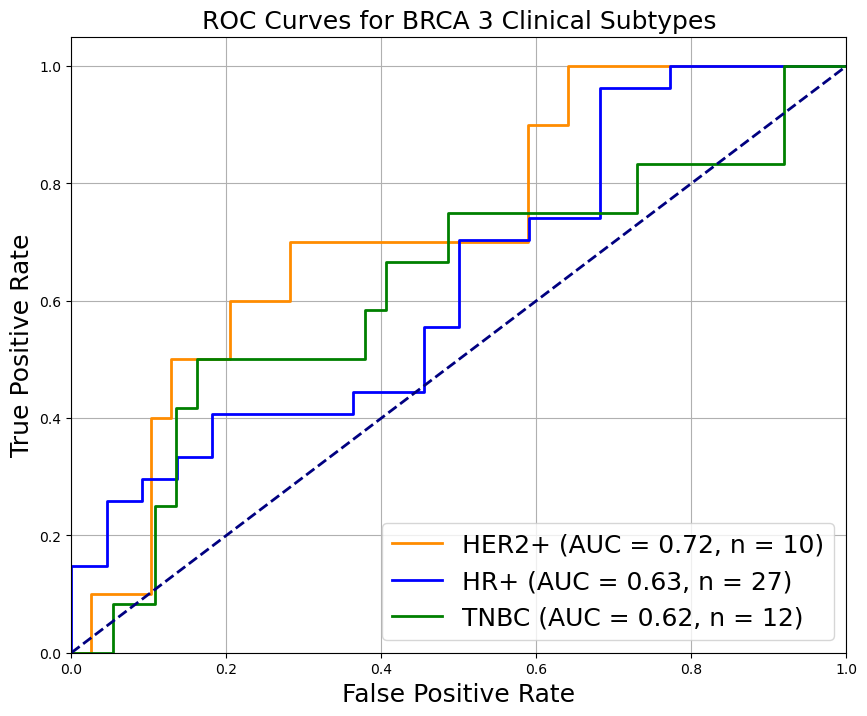

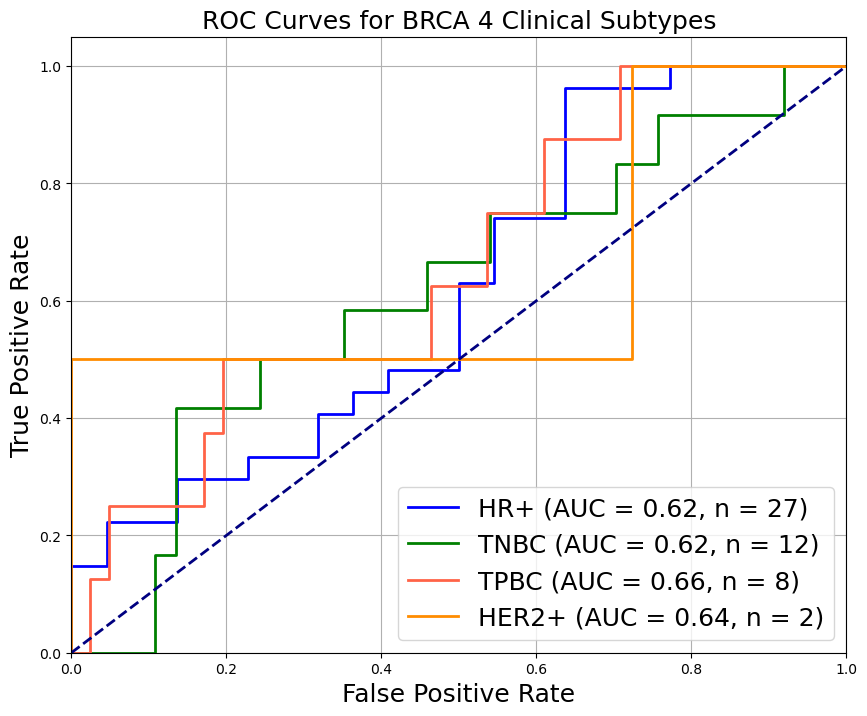

In [8]:
plot_combined_roc_curves(
    external_predictions_df,
    subtypes_3,
    'ROC Curves for BRCA 3 Clinical Subtypes',
    'roc_3_subtypes.png'
)

plot_combined_roc_curves(
    external_predictions_df,
    subtypes_4,
    'ROC Curves for BRCA 4 Clinical Subtypes',
    'roc_4_subtypes.png'
)

